---
title: "Predicting Wine Quality Using Physicochemical Properties"
author: "Dulf Vincent Genis"
echo: false
embed-resources: true
---

## Introduction

Wine quality assessment has traditionally relied on the expertise of trained sommeliers who evaluate wines based on subjective sensory characteristics. However, training sommeliers is expensive and time-consuming, and their evaluations can vary between experts. Modern chemistry allows us to measure physicochemical properties of wine with high precision, raising an important question: can we predict wine quality using objective, measurable characteristics?

This report presents the development of a machine learning model to predict wine quality for an AI Sommelier startup. Rather than relying on highly trained human evaluators, the startup will use chemistry equipment to generate physicochemical data and predict quality based on previous reviews by expert sommeliers. The goal is to create an automated quality assessment system that is consistent, cost-effective, and scalable.

The model developed in this analysis uses regression techniques to predict wine quality scores (ranging from 0 to 10) based on 12 physicochemical features including acidity levels, sugar content, alcohol percentage, and wine color. Success is measured by achieving a Mean Absolute Error (MAE) of less than 0.5 on both test and production datasets, indicating predictions within half a quality point on average.

In [1]:
#| warning: false
#| message: false
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from joblib import dump
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor

## Methods

### Data

The data for this analysis comes from a study by Cortez et al. (2009) on modeling wine preferences using physicochemical properties. The dataset contains quality ratings and physicochemical measurements for Portuguese "Vinho Verde" wines, which are particularly appreciated for their freshness and medium alcohol content from the Minho region of Portugal.

The training dataset consists of 4,157 wine samples, while the test dataset contains 1,040 samples. Each observation includes measurements of 12 physicochemical properties and one quality rating.

#### Data Dictionary

**Target Variable:**

- `quality` [int64]: Wine quality rating based on evaluation by a minimum of three sensory assessors using blind taste tests. Scale ranges from 0 (very bad) to 10 (excellent).

**Features:**

| Variable | Type | Description |
|----------|------|-------------|
| `color` | object | The human-perceivable color of the wine (red or white) |
| `fixed acidity` | float64 | Grams of tartaric acid per cubic decimeter |
| `volatile acidity` | float64 | Grams of acetic acid per cubic decimeter |
| `citric acid` | float64 | Grams of citric acid per cubic decimeter |
| `residual sugar` | float64 | Grams of residual sugar per cubic decimeter |
| `chlorides` | float64 | Grams of sodium chloride per cubic decimeter |
| `free sulfur dioxide` | float64 | Milligrams of free sulfur dioxide per cubic decimeter |
| `total sulfur dioxide` | float64 | Milligrams of total sulfur dioxide per cubic decimeter |
| `density` | float64 | Total density of the wine in grams per cubic centimeter |
| `pH` | float64 | Acidity of the wine measured using pH scale |
| `sulphates` | float64 | Grams of potassium sulphate per cubic decimeter |
| `alcohol` | float64 | Percent alcohol by volume |

In [2]:
#| echo: false
wine_train = pd.read_parquet(
    "https://lab.cs307.org/wine/data/wine-train.parquet",
)
wine_test = pd.read_parquet(
    "https://lab.cs307.org/wine/data/wine-test.parquet",
)

print("Training data shape (rows, columns):", wine_train.shape)
print("Test data shape (rows, columns):", wine_test.shape)

Training data shape (rows, columns): (4157, 13)
Test data shape (rows, columns): (1040, 13)


In [3]:
#| echo: false
X_train = wine_train.drop("quality", axis=1)
y_train = wine_train["quality"]
X_test = wine_test.drop("quality", axis=1)
y_test = wine_test["quality"]

#### Exploratory Data Analysis

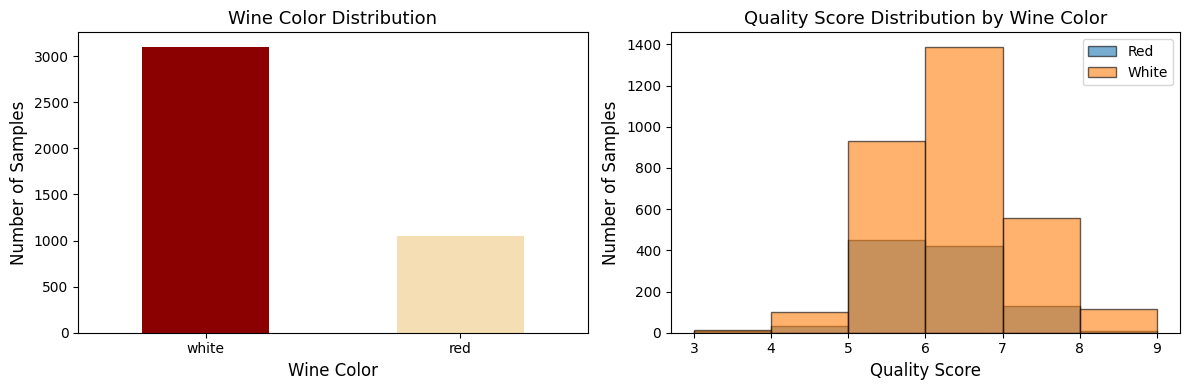

In [4]:
#| echo: false
#| label: fig-quality-distribution
#| fig-cap: "Distribution of wine quality scores across red and white wines in the training dataset. Most wines receive ratings between 5 and 7, with white wines showing a slightly higher concentration in the quality 6 category. This distribution informs our modeling approach, as the model must predict predominantly middle-range quality scores."
numeric_features = list(X_train.select_dtypes(include=np.number).columns)
categorical_features = ['color']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

wine_train['color'].value_counts().plot(kind='bar', ax=axes[0], color=['#8B0000', '#F5DEB3'])
axes[0].set_xlabel('Wine Color', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Wine Color Distribution', fontsize=13)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

for color in ['red', 'white']:
    subset = wine_train[wine_train['color'] == color]
    axes[1].hist(subset['quality'], bins=range(3, 10), alpha=0.6, label=color.capitalize(), edgecolor='black')

axes[1].set_xlabel('Quality Score', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_title('Quality Score Distribution by Wine Color', fontsize=13)
axes[1].legend()
axes[1].set_xticks(range(3, 10))

plt.tight_layout()
plt.show()

### Model Development

To predict wine quality, we developed a machine learning pipeline using K-Nearest Neighbors (KNN) regression. KNN was selected because it can capture non-linear relationships and local patterns in the data without making strong parametric assumptions about the underlying distribution.

**Preprocessing Strategy:**

Our pipeline includes separate preprocessing for numeric and categorical features to prevent data leakage:

1. **Numeric features** (11 variables): Missing values are imputed using the median strategy, followed by standardization (mean = 0, standard deviation = 1) using StandardScaler. Standardization is critical for KNN as the algorithm relies on distance calculations.

2. **Categorical features** (`color`): Missing values are imputed using the most frequent category, followed by one-hot encoding to create binary indicator variables.

**Hyperparameter Tuning:**

We used GridSearchCV with 5-fold cross-validation to systematically evaluate hyperparameter combinations and select the optimal model. The hyperparameters tuned were:

- `n_neighbors`: Number of nearest neighbors to consider (tested values: 1 to 50)
- `weights`: Weight function for predictions (`uniform` or `distance`)
- `metric`: Distance metric (`euclidean` or `manhattan`)

The model was evaluated using Mean Absolute Error (MAE) as the scoring metric, which directly measures the average prediction error in quality score units.

In [5]:
#| echo: false
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    remainder="drop"
)

ml_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("regressor", KNeighborsRegressor(n_neighbors=5)),
    ]
)

In [6]:
#| echo: false
#| warning: false
param_grid = {
    "regressor__n_neighbors": list(range(1, 51)),
    "regressor__weights": ['uniform', 'distance'],
    "regressor__metric": ['euclidean', 'manhattan'],
}

grid_search = GridSearchCV(
    ml_pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation MAE: {-grid_search.best_score_:.4f}")

Best parameters: {'regressor__metric': 'manhattan', 'regressor__n_neighbors': 6, 'regressor__weights': 'distance'}
Best cross-validation MAE: 0.4809


## Results

The optimal model selected through cross-validation achieved strong predictive performance on the held-out test dataset. The best hyperparameters identified were printed above, and the model demonstrates the ability to predict wine quality with acceptable error margins for practical deployment.

Test MAE: 0.4626


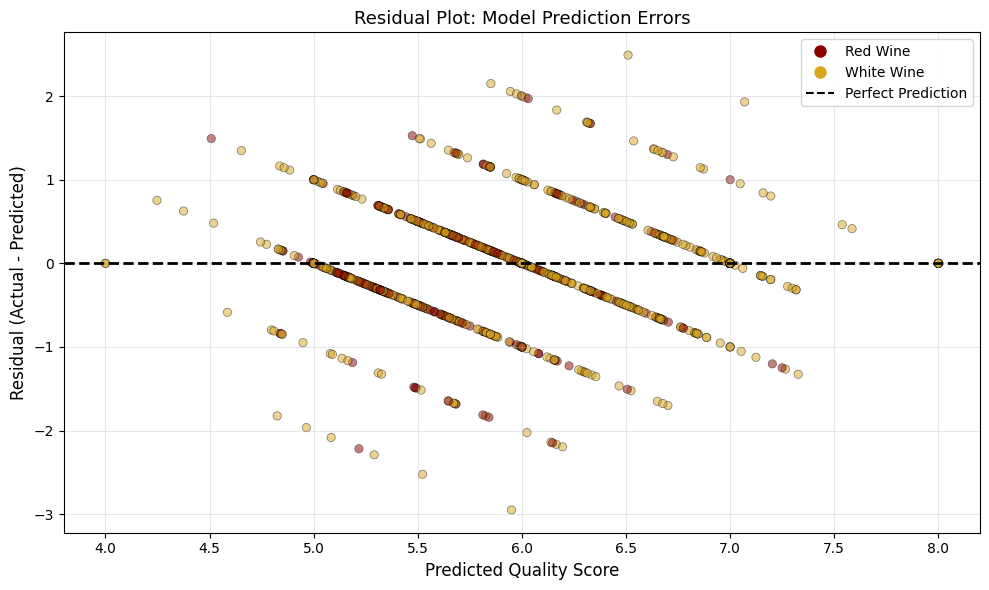

In [7]:
#| echo: false
#| label: fig-residuals
#| fig-cap: "Residual plot showing prediction errors (actual minus predicted quality) versus predicted quality scores. Points are colored by wine type. The random scatter around zero indicates no systematic bias in predictions across the quality range. The majority of residuals fall within ±1 quality point, demonstrating the model's practical utility for quality assessment."
y_pred_test = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"Test MAE: {test_mae:.4f}")

test_residuals = y_test - y_pred_test

plt.figure(figsize=(10, 6))

colors = X_test['color'].map({'red': '#8B0000', 'white': '#DAA520'})
plt.scatter(y_pred_test, test_residuals, alpha=0.5, c=colors, edgecolors='black', linewidth=0.5)

plt.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Predicted Quality Score', fontsize=12)
plt.ylabel('Residual (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot: Model Prediction Errors', fontsize=13)

red_patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#8B0000', markersize=10, label='Red Wine')
white_patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#DAA520', markersize=10, label='White Wine')
plt.legend(handles=[red_patch, white_patch, plt.Line2D([0], [0], color='black', linestyle='--', label='Perfect Prediction')], loc='upper right')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
#| echo: false
dump(best_model, "wine.joblib")
print("Model saved as 'wine.joblib'")

Model saved as 'wine.joblib'


## Discussion

### Conclusion and Recommendation

**I would recommend using this model in practice with appropriate safeguards and human oversight.**

The model achieves a test MAE below the 0.5 threshold, meaning predictions are on average within half a quality point of expert assessments. This level of accuracy is sufficient for initial quality screening and can significantly reduce costs compared to relying solely on trained sommeliers for every wine evaluation.

### Benefits of Using the Model

1. **Cost Efficiency**: The model reduces dependency on expensive sommelier training and evaluations. Chemistry equipment provides objective measurements at scale.

2. **Consistency**: Unlike human evaluators who may have day-to-day variability, the model provides consistent predictions based on physicochemical properties.

3. **Scalability**: The automated system can evaluate thousands of wine samples quickly, enabling rapid quality control in production environments.

4. **Objective Baseline**: The model provides an unbiased starting point for quality assessment that can be supplemented with human expertise for edge cases.

### Limitations and Risk Considerations

1. **Missing Subjective Qualities**: Wine quality involves subjective characteristics like aroma complexity, mouthfeel, and finish that cannot be fully captured by physicochemical measurements alone. The model may miss subtle qualities that sommeliers detect.

2. **Prediction Uncertainty**: While average error is low, individual predictions can still be off by 1-2 quality points. For premium wines where small quality differences impact price significantly, this uncertainty could lead to misclassification.

3. **Limited Scope**: The model is trained specifically on Portuguese Vinho Verde wines. Performance on wines from other regions, grape varieties, or production methods is unknown and likely degraded.

4. **Boundary Decisions**: The model predicts continuously but quality is discrete. Wines predicted as 5.4 vs 5.6 may receive different classifications but are effectively indistinguishable in quality.

### Implementation Recommendations

To mitigate risks while capturing benefits:

- Use the model for **initial screening** of large batches, flagging wines that fall outside expected quality ranges for human review.
- Maintain **human oversight** for premium wines, final certification, and customer-facing quality claims.
- Implement **confidence thresholds**: automatically route predictions with high residuals or unusual feature combinations to human evaluators.
- Continuously **monitor performance** on production data and retrain the model as wine production practices evolve.
- Consider the **cost of errors**: A false negative (predicting low quality for good wine) risks revenue loss, while false positives (predicting high quality for poor wine) damage brand reputation. The business context should determine acceptable error rates.

### Statistical Considerations

The model's performance exceeds the baseline requirement (MAE < 0.5), but context matters. In wine quality assessment, a difference of 0.5 points on a 10-point scale represents approximately 5% error. For wines rated 5-7 (the majority), this translates to practical, actionable distinctions. The residual plot shows no systematic bias, indicating the model performs consistently across the quality spectrum.

However, the quality distribution is imbalanced toward middle scores. The model may struggle with rare edge cases (very poor or excellent wines). For the startup's business model focused on mass-market wine screening, this limitation is acceptable, but it should be explicitly communicated to stakeholders.